In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Zomato-data-.csv')
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [3]:
df.shape

(148, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [5]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [6]:
def handlerate(value):
    value=str(value).split('/')
    value=value[0]
    return float(value)

df['rate']=df['rate'].apply(handlerate)
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [8]:
df.describe()

,rate,votes,approx_cost(for two people)
count,148.000000,148.000000,148.000000
mean,3.633108,264.810811,418.243243
std,0.402271,653.676951,223.085098
min,2.600000,0.000000,100.000000
25%,3.300000,6.750000,200.000000
50%,3.700000,43.500000,400.000000
75%,3.900000,221.750000,600.000000
max,4.600000,4884.000000,950.000000


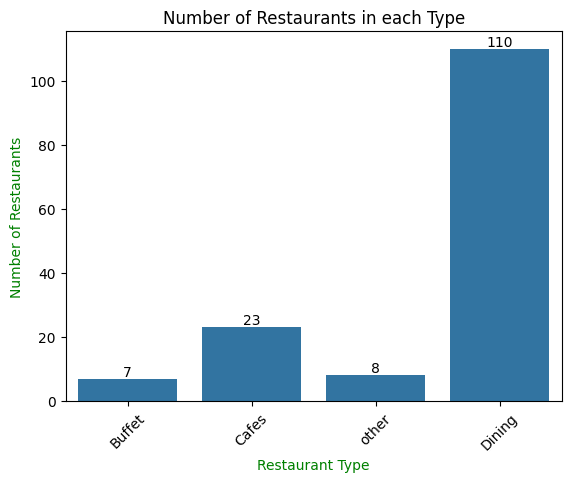

In [9]:
ax=sns.countplot(x='listed_in(type)',data=df)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45)
plt.title('Number of Restaurants in each Type')
plt.xlabel('Restaurant Type',c='green')
plt.ylabel('Number of Restaurants',c='green')
plt.show()

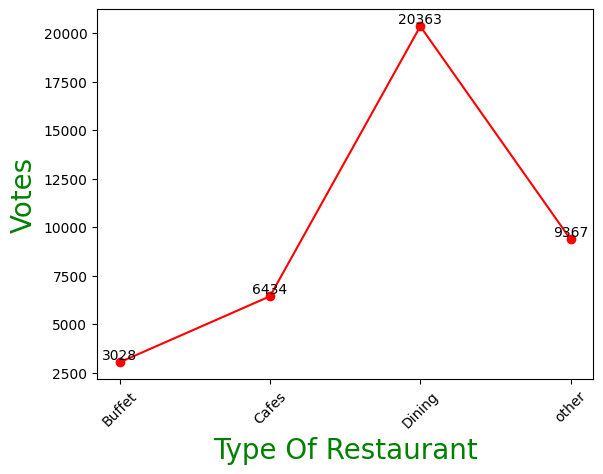

In [10]:
gb = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'Type Of Restaurant': gb.index, 'Votes': gb.values})
plt.plot(result['Type Of Restaurant'], result['Votes'], color='red', marker='o')
for i, value in enumerate(result['Votes']):
    plt.text(i, value, str(value), ha='center', va='bottom', fontsize=10, color='black')
plt.xlabel("Type Of Restaurant", c='green', size=20)
plt.ylabel("Votes", c='green', size=20)
plt.xticks(rotation=45)
plt.show()

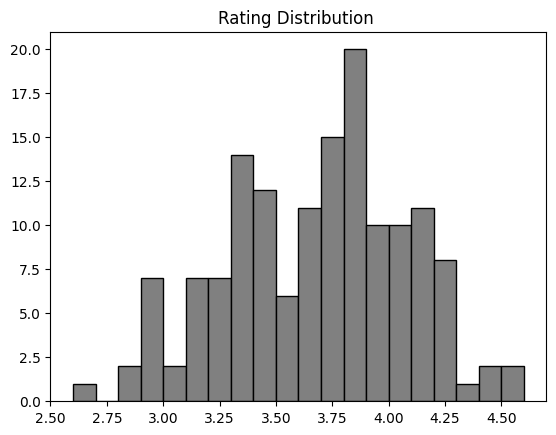

In [11]:
plt.hist(df['rate'], bins=20, color='grey', edgecolor='black')
plt.title("Rating Distribution ")
plt.show()

C:\Users\sk191\AppData\Local\Temp\ipykernel_11652\2309143253.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=couple, data=df, palette='Set2')


<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

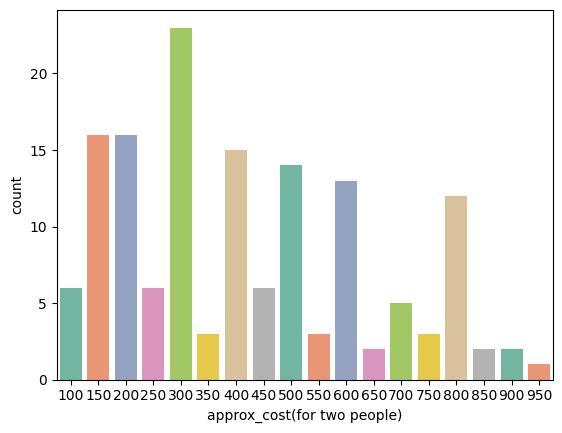

In [12]:
couple=df['approx_cost(for two people)']
sns.countplot(x=couple, data=df, palette='Set2')

Text(0.5, 1.0, 'Online Order Distribution')

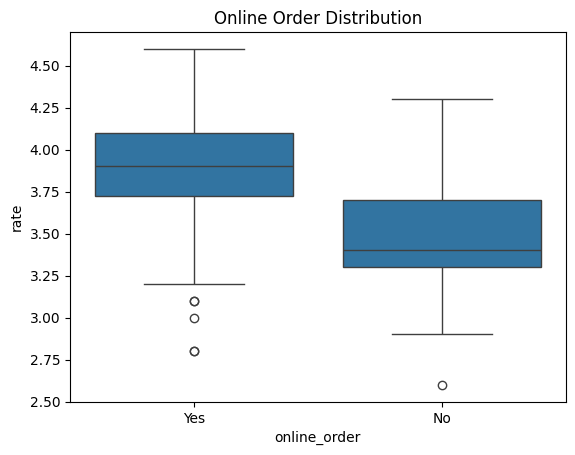

In [13]:
sns.boxplot(x='online_order',y='rate', data=df
            )
plt.title('Online Order Distribution')

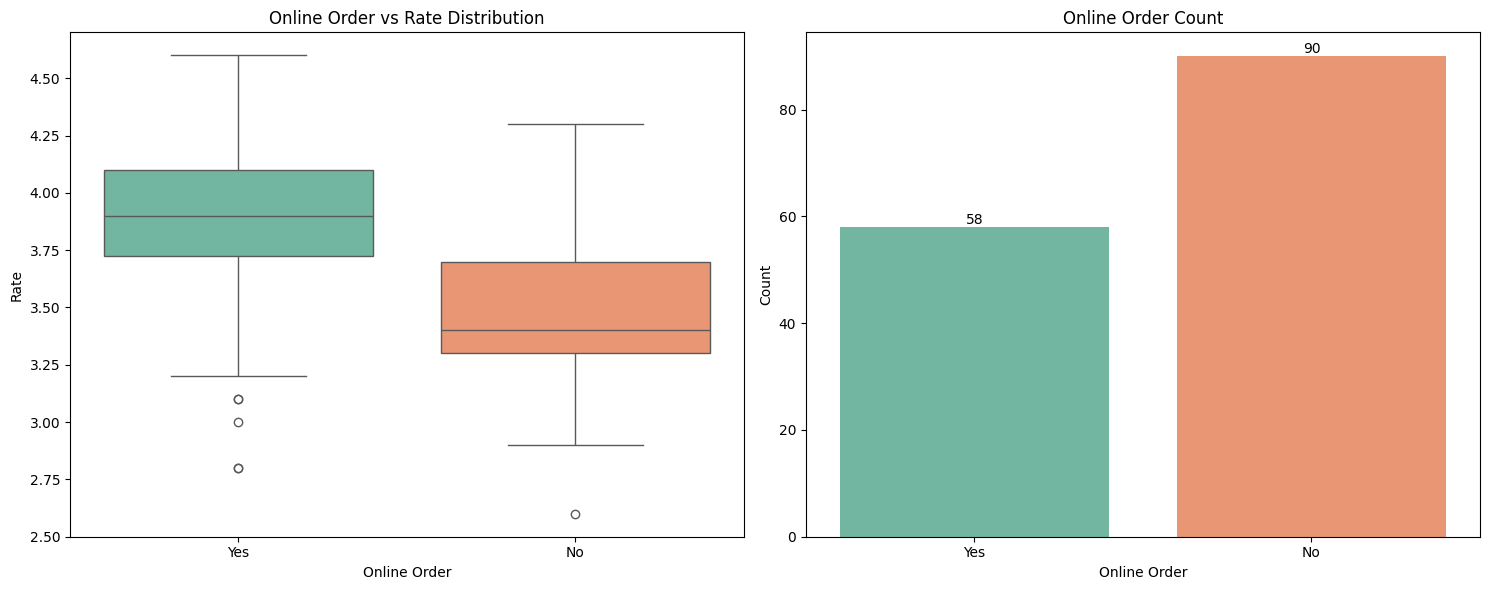

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot
sns.boxplot(x='online_order', y='rate', data=df, palette='Set2', hue='online_order', ax=axes[0], legend=False)
axes[0].set_title('Online Order vs Rate Distribution')
axes[0].set_xlabel('Online Order')
axes[0].set_ylabel('Rate')

# Countplot
sns.countplot(x='online_order', data=df, palette='Set2', hue='online_order', ax=axes[1], legend=False)
axes[1].set_title('Online Order Count')
axes[1].set_xlabel('Online Order')
axes[1].set_ylabel('Count')

# Add counts on top of the bars in the countplot
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', label_type='edge', fontsize=10, color='black')

plt.tight_layout()
plt.show()

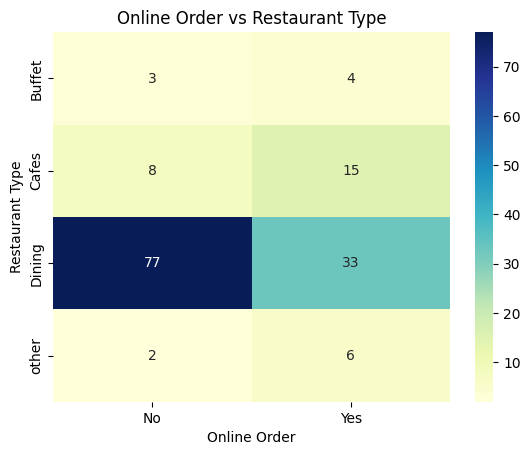

In [15]:
pivot = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Online Order vs Restaurant Type')
plt.xlabel('Online Order')
plt.ylabel('Restaurant Type')
plt.show()